# Machine Learning - 1

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
data_url = " https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
data = pd.read_csv(data_url + "telecom_churn.csv")
data

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,Yes,No,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


Check the data

In [37]:
data.dtypes,data.columns

(State                      object
 Account length              int64
 Area code                   int64
 International plan         object
 Voice mail plan            object
 Number vmail messages       int64
 Total day minutes         float64
 Total day calls             int64
 Total day charge          float64
 Total eve minutes         float64
 Total eve calls             int64
 Total eve charge          float64
 Total night minutes       float64
 Total night calls           int64
 Total night charge        float64
 Total intl minutes        float64
 Total intl calls            int64
 Total intl charge         float64
 Customer service calls      int64
 Churn                        bool
 dtype: object,
 Index(['State', 'Account length', 'Area code', 'International plan',
        'Voice mail plan', 'Number vmail messages', 'Total day minutes',
        'Total day calls', 'Total day charge', 'Total eve minutes',
        'Total eve calls', 'Total eve charge', 'Total night minutes',
   

In [38]:
data.shape

(3333, 20)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [40]:
data.select_dtypes(exclude = ["object"])

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,415,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,68,415,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,28,510,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,184,510,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [41]:
data.Churn 

0       False
1       False
2       False
3       False
4       False
        ...  
3328    False
3329    False
3330    False
3331    False
3332    False
Name: Churn, Length: 3333, dtype: bool

In [42]:
data.Churn = data.Churn.astype("int64")

In [43]:
data.Churn

0       0
1       0
2       0
3       0
4       0
       ..
3328    0
3329    0
3330    0
3331    0
3332    0
Name: Churn, Length: 3333, dtype: int64

In [44]:
data.Churn.value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

In [45]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Account length,3333.0,101.064806,39.822106,1.00,74.00,101.00,127.00,243.00
Area code,3333.0,437.182418,42.371290,408.00,408.00,415.00,510.00,510.00
Number vmail messages,3333.0,8.099010,13.688365,0.00,0.00,0.00,20.00,51.00
Total day minutes,3333.0,179.775098,54.467389,0.00,143.70,179.40,216.40,350.80
Total day calls,3333.0,100.435644,20.069084,0.00,87.00,101.00,114.00,165.00
Total day charge,3333.0,30.562307,9.259435,0.00,24.43,30.50,36.79,59.64
Total eve minutes,3333.0,200.980348,50.713844,0.00,166.60,201.40,235.30,363.70
Total eve calls,3333.0,100.114311,19.922625,0.00,87.00,100.00,114.00,170.00
Total eve charge,3333.0,17.083540,4.310668,0.00,14.16,17.12,20.00,30.91
Total night minutes,3333.0,200.872037,50.573847,23.20,167.00,201.20,235.30,395.00


In [46]:
data.describe(include = ["float"])

,Total day minutes,Total day charge,Total eve minutes,Total eve charge,Total night minutes,Total night charge,Total intl minutes,Total intl charge
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,179.775098,30.562307,200.980348,17.083540,200.872037,9.039325,10.237294,2.764581
std,54.467389,9.259435,50.713844,4.310668,50.573847,2.275873,2.791840,0.753773
min,0.000000,0.000000,0.000000,0.000000,23.200000,1.040000,0.000000,0.000000
25%,143.700000,24.430000,166.600000,14.160000,167.000000,7.520000,8.500000,2.300000
50%,179.400000,30.500000,201.400000,17.120000,201.200000,9.050000,10.300000,2.780000
75%,216.400000,36.790000,235.300000,20.000000,235.300000,10.590000,12.100000,3.270000
max,350.800000,59.640000,363.700000,30.910000,395.000000,17.770000,20.000000,5.400000


In [47]:
data.describe(include = ["object"]).T

,count,unique,top,freq
State,3333,51,WV,106
International plan,3333,2,No,3010
Voice mail plan,3333,2,No,2411


In [48]:
data.Churn.value_counts(normalize=True)

Churn
0    0.855086
1    0.144914
Name: proportion, dtype: float64

In [49]:
data.Churn.value_counts(normalize = False)

Churn
0    2850
1     483
Name: count, dtype: int64

Sorting

In [50]:
data.sort_values(by = "Total day charge",ascending = False).head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
365,CO,154,415,No,No,0,350.8,75,59.64,216.5,94,18.40,253.9,100,11.43,10.1,9,2.73,1,1
985,NY,64,415,Yes,No,0,346.8,55,58.96,249.5,79,21.21,275.4,102,12.39,13.3,9,3.59,1,1
2594,OH,115,510,Yes,No,0,345.3,81,58.70,203.4,106,17.29,217.5,107,9.79,11.8,8,3.19,1,1
156,OH,83,415,No,No,0,337.4,120,57.36,227.4,116,19.33,153.9,114,6.93,15.8,7,4.27,0,1
605,MO,112,415,No,No,0,335.5,77,57.04,212.5,109,18.06,265.0,132,11.93,12.7,8,3.43,2,1


In [51]:
data.sort_values(by = "Total day charge",ascending = True).head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
1345,SD,98,415,No,No,0,0.0,0,0.00,159.6,130,13.57,167.1,88,7.52,6.8,1,1.84,4,1
1397,VT,101,510,No,No,0,0.0,0,0.00,192.1,119,16.33,168.8,95,7.60,7.2,4,1.94,1,0
2736,OK,127,510,No,Yes,27,2.6,113,0.44,254.0,102,21.59,242.7,156,10.92,9.2,5,2.48,3,0
2753,OH,134,415,No,No,0,7.8,86,1.33,171.4,100,14.57,186.5,80,8.39,12.9,2,3.48,2,0
1986,WI,70,415,No,No,0,7.9,100,1.34,136.4,83,11.59,156.6,89,7.05,12.1,1,3.27,0,0


In [52]:
data.sort_values(by = ["Churn","Total day charge"],ascending= [True,False]).head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
688,MN,13,510,No,Yes,21,315.6,105,53.65,208.9,71,17.76,260.1,123,11.70,12.1,3,3.27,3,0
2259,NC,210,415,No,Yes,31,313.8,87,53.35,147.7,103,12.55,192.7,97,8.67,10.1,7,2.73,3,0
534,LA,67,510,No,No,0,310.4,97,52.77,66.5,123,5.65,246.5,99,11.09,9.2,10,2.48,4,0
575,SD,114,415,No,Yes,36,309.9,90,52.68,200.3,89,17.03,183.5,105,8.26,14.2,2,3.83,1,0
2858,AL,141,510,No,Yes,28,308.0,123,52.36,247.8,128,21.06,152.9,103,6.88,7.4,3,2.00,1,0


In [53]:
# Example until now

df = pd.DataFrame({"a":np.arange(1,10)})
df

,a
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9


In [54]:
df.sort_values(by ="a",ascending=True )

,a
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9


In [55]:
df.sort_values(by="a",ascending = False)

,a
8,9
7,8
6,7
5,6
4,5
3,4
2,3
1,2
0,1


# Indexing and Retrieving Data

In [56]:
data["Churn"].mean()

np.float64(0.14491449144914492)

In [57]:
data.select_dtypes(include = np.number)[data["Churn"] == 1].mean()

Account length            102.664596
Area code                 437.817805
Number vmail messages       5.115942
Total day minutes         206.914079
Total day calls           101.335404
Total day charge           35.175921
Total eve minutes         212.410145
Total eve calls           100.561077
Total eve charge           18.054969
Total night minutes       205.231677
Total night calls         100.399586
Total night charge          9.235528
Total intl minutes         10.700000
Total intl calls            4.163561
Total intl charge           2.889545
Customer service calls      2.229814
Churn                       1.000000
dtype: float64

In [58]:
data.select_dtypes(include =np.number)[data["Churn"] == 0].mean()

Account length            100.793684
Area code                 437.074737
Number vmail messages       8.604561
Total day minutes         175.175754
Total day calls           100.283158
Total day charge           29.780421
Total eve minutes         199.043298
Total eve calls           100.038596
Total eve charge           16.918909
Total night minutes       200.133193
Total night calls         100.058246
Total night charge          9.006074
Total intl minutes         10.158877
Total intl calls            4.532982
Total intl charge           2.743404
Customer service calls      1.449825
Churn                       0.000000
dtype: float64

In [59]:
data[data["Churn"]==1]["Total day minutes"].mean()

np.float64(206.91407867494823)

In [60]:
data[data["Churn"]==0]["Total day minutes"].mean()

np.float64(175.1757543859649)

In [61]:
data[(data["Churn"]==0) & (data["International plan" == "No"])]["Total intl minutes"].max()

KeyError: False

In [62]:
data[(data["Churn"] == 0) & (data["International plan"] == "No")]["Total intl minutes"].max()

np.float64(18.9)

In [ ]:
data.loc[:,"Churn"]

0       0
1       0
2       0
3       0
4       0
       ..
3328    0
3329    0
3330    0
3331    0
3332    0
Name: Churn, Length: 3333, dtype: int64

In [ ]:
data.loc[:5,["Churn","International plan"]]

,Churn,International plan
0,0,No
1,0,No
2,0,No
3,0,Yes
4,0,Yes
5,0,Yes


In [ ]:
data.loc[:0,["Churn","International plan"]]

,Churn,International plan
0,0,No


In [ ]:
data.loc[:5,"State":"Area code"]

,State,Account length,Area code
0,KS,128,415
1,OH,107,415
2,NJ,137,415
3,OH,84,408
4,OK,75,415
5,AL,118,510


In [ ]:
data.iloc[0:5,:1]

,State
0,KS
1,OH
2,NJ
3,OH
4,OK


In [ ]:
data.iloc[:5,:2]

,State,Account length
0,KS,128
1,OH,107
2,NJ,137
3,OH,84
4,OK,75


In [ ]:
data.iloc[:5,:3],data.loc[:5,"State":"Area code"]

(  State  Account length  Area code
 0    KS             128        415
 1    OH             107        415
 2    NJ             137        415
 3    OH              84        408
 4    OK              75        415,
   State  Account length  Area code
 0    KS             128        415
 1    OH             107        415
 2    NJ             137        415
 3    OH              84        408
 4    OK              75        415
 5    AL             118        510)

In [ ]:
data[-1:]

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
3332,TN,74,415,No,Yes,25,234.4,113,39.85,265.9,82,22.6,241.4,77,10.86,13.7,4,3.7,0,0


In [ ]:
data.State[-5:]

3328    AZ
3329    WV
3330    RI
3331    CT
3332    TN
Name: State, dtype: object

In [ ]:
data[-5:]

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
3328,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,0
3329,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,0
3330,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,0
3331,CT,184,510,Yes,No,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,0
3332,TN,74,415,No,Yes,25,234.4,113,39.85,265.9,82,22.60,241.4,77,10.86,13.7,4,3.70,0,0


# Applying functions to rows and columns

In [ ]:
data.apply(np.max)

State                        WY
Account length              243
Area code                   510
International plan          Yes
Voice mail plan             Yes
Number vmail messages        51
Total day minutes         350.8
Total day calls             165
Total day charge          59.64
Total eve minutes         363.7
Total eve calls             170
Total eve charge          30.91
Total night minutes       395.0
Total night calls           175
Total night charge        17.77
Total intl minutes         20.0
Total intl calls             20
Total intl charge           5.4
Customer service calls        9
Churn                         1
dtype: object

In [ ]:
data.apply(np.min)

State                       AK
Account length               1
Area code                  408
International plan          No
Voice mail plan             No
Number vmail messages        0
Total day minutes          0.0
Total day calls              0
Total day charge           0.0
Total eve minutes          0.0
Total eve calls              0
Total eve charge           0.0
Total night minutes       23.2
Total night calls           33
Total night charge        1.04
Total intl minutes         0.0
Total intl calls             0
Total intl charge          0.0
Customer service calls       0
Churn                        0
dtype: object

In [ ]:
data[data["State"].apply(lambda state: state[0] == "W")].head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
9,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,0
26,WY,57,408,No,Yes,39,213.0,115,36.21,191.1,112,16.24,182.7,115,8.22,9.5,3,2.57,0,0
44,WI,64,510,No,No,0,154.0,67,26.18,225.8,118,19.19,265.3,86,11.94,3.5,3,0.95,1,0
49,WY,97,415,No,Yes,24,133.2,135,22.64,217.2,58,18.46,70.6,79,3.18,11.0,3,2.97,1,0
54,WY,87,415,No,No,0,151.0,83,25.67,219.7,116,18.67,203.9,127,9.18,9.7,3,2.62,5,1


In [ ]:
data[data["State"].apply(lambda state: state[1] == "I")].head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
11,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,0
29,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,0
44,WI,64,510,No,No,0,154.0,67,26.18,225.8,118,19.19,265.3,86,11.94,3.5,3,0.95,1,0
46,MI,65,415,No,No,0,211.3,120,35.92,162.6,122,13.82,134.7,118,6.06,13.2,5,3.56,3,0
58,WI,68,415,No,No,0,148.8,70,25.30,246.5,164,20.95,129.8,103,5.84,12.1,3,3.27,3,0


In [ ]:
d = {"No":False,"Yes":True}
data["International plan"] = data["International plan"].map(d)
data

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,False,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,False,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,False,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,True,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,True,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,False,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,0
3329,WV,68,415,False,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,0
3330,RI,28,510,False,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,0
3331,CT,184,510,True,No,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,0


In [ ]:
data["Voice mail plan"] = data["Voice mail plan"].map(d)

In [ ]:
data

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,False,True,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,False,True,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,False,False,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,True,False,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,True,False,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,False,True,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,0
3329,WV,68,415,False,False,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,0
3330,RI,28,510,False,False,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,0
3331,CT,184,510,True,False,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,0


# Grouping

In [ ]:
data.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [ ]:
columns_show = ["Total day minutes","Total day charge","Total day calls"]
data.groupby(["Churn"])[columns_show].mean()

,Total day minutes,Total day charge,Total day calls
Churn,,,
0,175.175754,29.780421,100.283158
1,206.914079,35.175921,101.335404


In [ ]:
data.groupby(["Churn"])[columns_show].describe(percentiles=[])

Total day minutes                                            \
                  count        mean        std  min    50%    max   
Churn                                                               
0                2850.0  175.175754  50.181655  0.0  177.2  315.6   
1                 483.0  206.914079  68.997792  0.0  217.6  350.8   

      Total day charge                                           \
                 count       mean        std  min    50%    max   
Churn                                                             
0               2850.0  29.780421   8.530835  0.0  30.12  53.65   
1                483.0  35.175921  11.729710  0.0  36.99  59.64   

      Total day calls                                            
                count        mean        std  min    50%    max  
Churn                                                            
0              2850.0  100.283158  19.801157  0.0  100.0  163.0  
1               483.0  101.335404  21.582307  0.0  103.0  165.0

In [ ]:
data.groupby(["Churn"])[columns_show].agg(["min","max","mean","std"])

Total day minutes                               Total day charge         \
                    min    max        mean        std              min    max   
Churn                                                                           
0                   0.0  315.6  175.175754  50.181655              0.0  53.65   
1                   0.0  350.8  206.914079  68.997792              0.0  59.64   

                            Total day calls                              
            mean        std             min  max        mean        std  
Churn                                                                    
0      29.780421   8.530835               0  163  100.283158  19.801157  
1      35.175921  11.729710               0  165  101.335404  21.582307

# Summary Tables

In [63]:
pd.crosstab(data["Churn"],data["International plan"])

International plan,No,Yes
Churn,,
0,2664,186
1,346,137


In [65]:
pd.crosstab(data["Churn"],data["Voice mail plan"],normalize=True)

Voice mail plan,No,Yes
Churn,,
0,0.602460,0.252625
1,0.120912,0.024002


In [68]:
pd.crosstab(data["Churn"],data["State"])

State,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
Churn,,,,,,,,,,,,,,,,,,,,,
0,49,72,44,60,25,57,62,49,52,55,...,52,48,54,62,72,65,52,71,96,68
1,3,8,11,4,9,9,12,5,9,8,...,8,5,18,10,5,8,14,7,10,9


In [69]:
data.pivot_table(["Total day calls","Total eve calls","Total night calls"],["Area code"],aggfunc="mean")

,Total day calls,Total eve calls,Total night calls
Area code,,,
408,100.496420,99.788783,99.039379
415,100.576435,100.503927,100.398187
510,100.097619,99.671429,100.601190


In [70]:
data.pivot_table(["Total night calls","Total day calls","Total eve calls"],["State"],aggfunc="mean")

,Total day calls,Total eve calls,Total night calls
State,,,
AK,95.269231,96.576923,97.346154
AL,99.100000,98.462500,98.612500
AR,102.145455,97.836364,99.054545
AZ,100.109375,102.406250,99.984375
CA,104.500000,103.088235,99.205882
CO,95.121212,98.166667,97.060606
CT,98.432432,99.121622,102.283784
DC,100.166667,101.981481,97.666667
DE,98.639344,97.360656,101.213115


In [71]:
data.pivot_table(["Total day calls","Total eve calls","Total night calls"],["International plan"],aggfunc=["max","min","mean"])

max                                    \
                   Total day calls Total eve calls Total night calls   
International plan                                                     
No                             165             170               175   
Yes                            146             159               154   

                               min                                    \
                   Total day calls Total eve calls Total night calls   
International plan                                                     
No                               0               0                33   
Yes                             42              50                48   

                              mean                                    
                   Total day calls Total eve calls Total night calls  
International plan                                                    
No                      100.410963      100.074419        100.027907  
Yes                     100.665635      100.486068        100.851393

# DataFrame Transformations

In [72]:
total_calls = (data["Total day calls"]+data["Total eve calls"] + data["Total night calls"] + data["Total intl calls"])
data.insert(loc=len(data.columns),column="Total calls",value=total_calls)

In [73]:
data.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Total calls
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,...,16.78,244.7,91,11.01,10.0,3,2.70,1,0,303
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,...,16.62,254.4,103,11.45,13.7,3,3.70,1,0,332
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,...,10.30,162.6,104,7.32,12.2,5,3.29,0,0,333
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,...,5.26,196.9,89,8.86,6.6,7,1.78,2,0,255
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,...,12.61,186.9,121,8.41,10.1,3,2.73,3,0,359


In [74]:
data.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn', 'Total calls'],
      dtype='object')

In [75]:
total_charge = (data["Total day charge"] + data["Total eve charge"] + data["Total night charge"] + data["Total intl charge"])
data.insert(loc = len(data.columns),column="Total Charge",value=total_charge)

In [76]:
data.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Total calls,Total Charge
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,...,244.7,91,11.01,10.0,3,2.70,1,0,303,75.56
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,...,254.4,103,11.45,13.7,3,3.70,1,0,332,59.24
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,...,162.6,104,7.32,12.2,5,3.29,0,0,333,62.29
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,...,196.9,89,8.86,6.6,7,1.78,2,0,255,66.80
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,...,186.9,121,8.41,10.1,3,2.73,3,0,359,52.09


In [78]:
df = pd.DataFrame({"col1":[1,2],"col2":[3,4]})
col3 = df["col1"] ** 2
df.insert(2,column = "col3",value = col3)
df

,col1,col2,col3
0,1,3,1
1,2,4,4


In [79]:
col4 = df["col3"]**2
df.insert(loc = len(df.columns),column="col4",value = col4)
df

,col1,col2,col3,col4
0,1,3,1,1
1,2,4,4,16


In [82]:
df.drop(["col3","col4"],axis = 1,inplace = True)
df

,col1,col2
0,1,3
1,2,4


# First Attempt to predict Telecom churn

In [83]:
pd.crosstab(data["Churn"],data["International plan"],margins = True)

International plan,No,Yes,All
Churn,,,
0,2664,186,2850
1,346,137,483
All,3010,323,3333


sns.countplot = Show the counts of observations in each categorical bin using bars.

<Axes: xlabel='International plan', ylabel='count'>

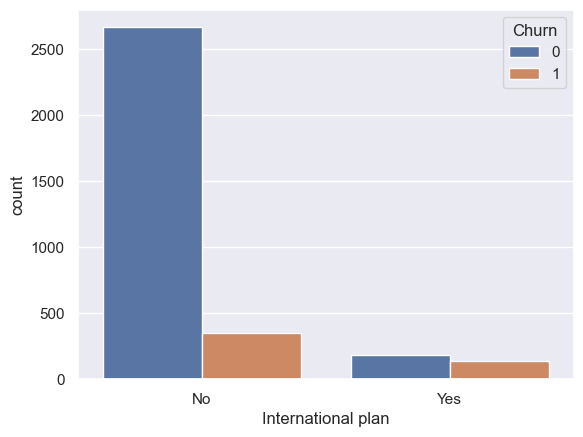

In [86]:
sns.set()
sns.countplot(x= "International plan",hue="Churn",data = data)

In [91]:
pd.crosstab(data["Customer service calls"],data["Churn"],margins = True).T

Customer service calls,0,1,2,3,4,5,6,7,8,9,All
Churn,,,,,,,,,,,
0,605,1059,672,385,90,26,8,4,1,0,2850
1,92,122,87,44,76,40,14,5,1,2,483
All,697,1181,759,429,166,66,22,9,2,2,3333


<Axes: xlabel='Customer service calls', ylabel='count'>

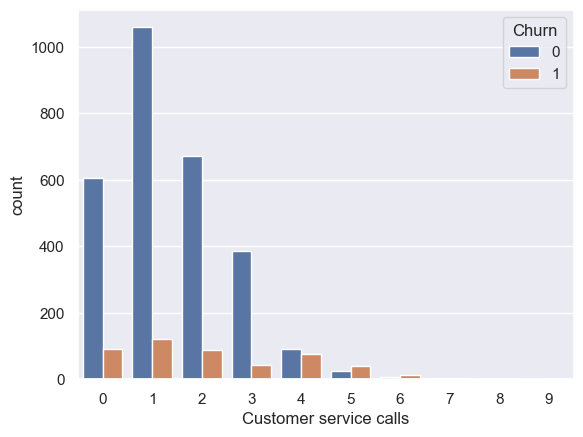

In [90]:
sns.countplot(data = data,x = "Customer service calls",hue = "Churn")

In [92]:
data["many_calls"] = (data["Customer service calls"] > 3 ).astype("int")

In [94]:
pd.crosstab(data["many_calls"],data["Churn"],margins = True)

Churn,0,1,All
many_calls,,,
0,2721,345,3066
1,129,138,267
All,2850,483,3333


<Axes: xlabel='many_calls', ylabel='count'>

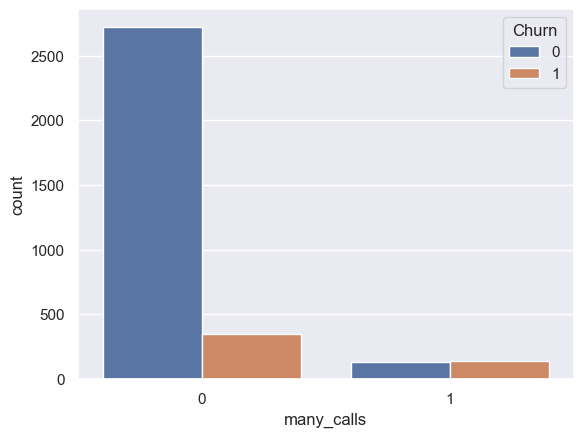

In [95]:
sns.countplot(x = "many_calls",hue="Churn",data = data)